In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('car_data.csv')

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.shape

(301, 9)

In [12]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [19]:
current_year = 2021
df['Year'] = current_year - df['Year']

In [20]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,7,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,8,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,4,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,10,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,7,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [24]:
df.drop(columns = ['Car_Name'], inplace = True)

In [25]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,7,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,8,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,4,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,10,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,7,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [26]:
newdf=pd.get_dummies(df,drop_first = True)
newdf.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,7,3.35,5.59,27000,0,False,True,False,True
1,8,4.75,9.54,43000,0,True,False,False,True
2,4,7.25,9.85,6900,0,False,True,False,True
3,10,2.85,4.15,5200,0,False,True,False,True
4,7,4.60,6.87,42450,0,True,False,False,True


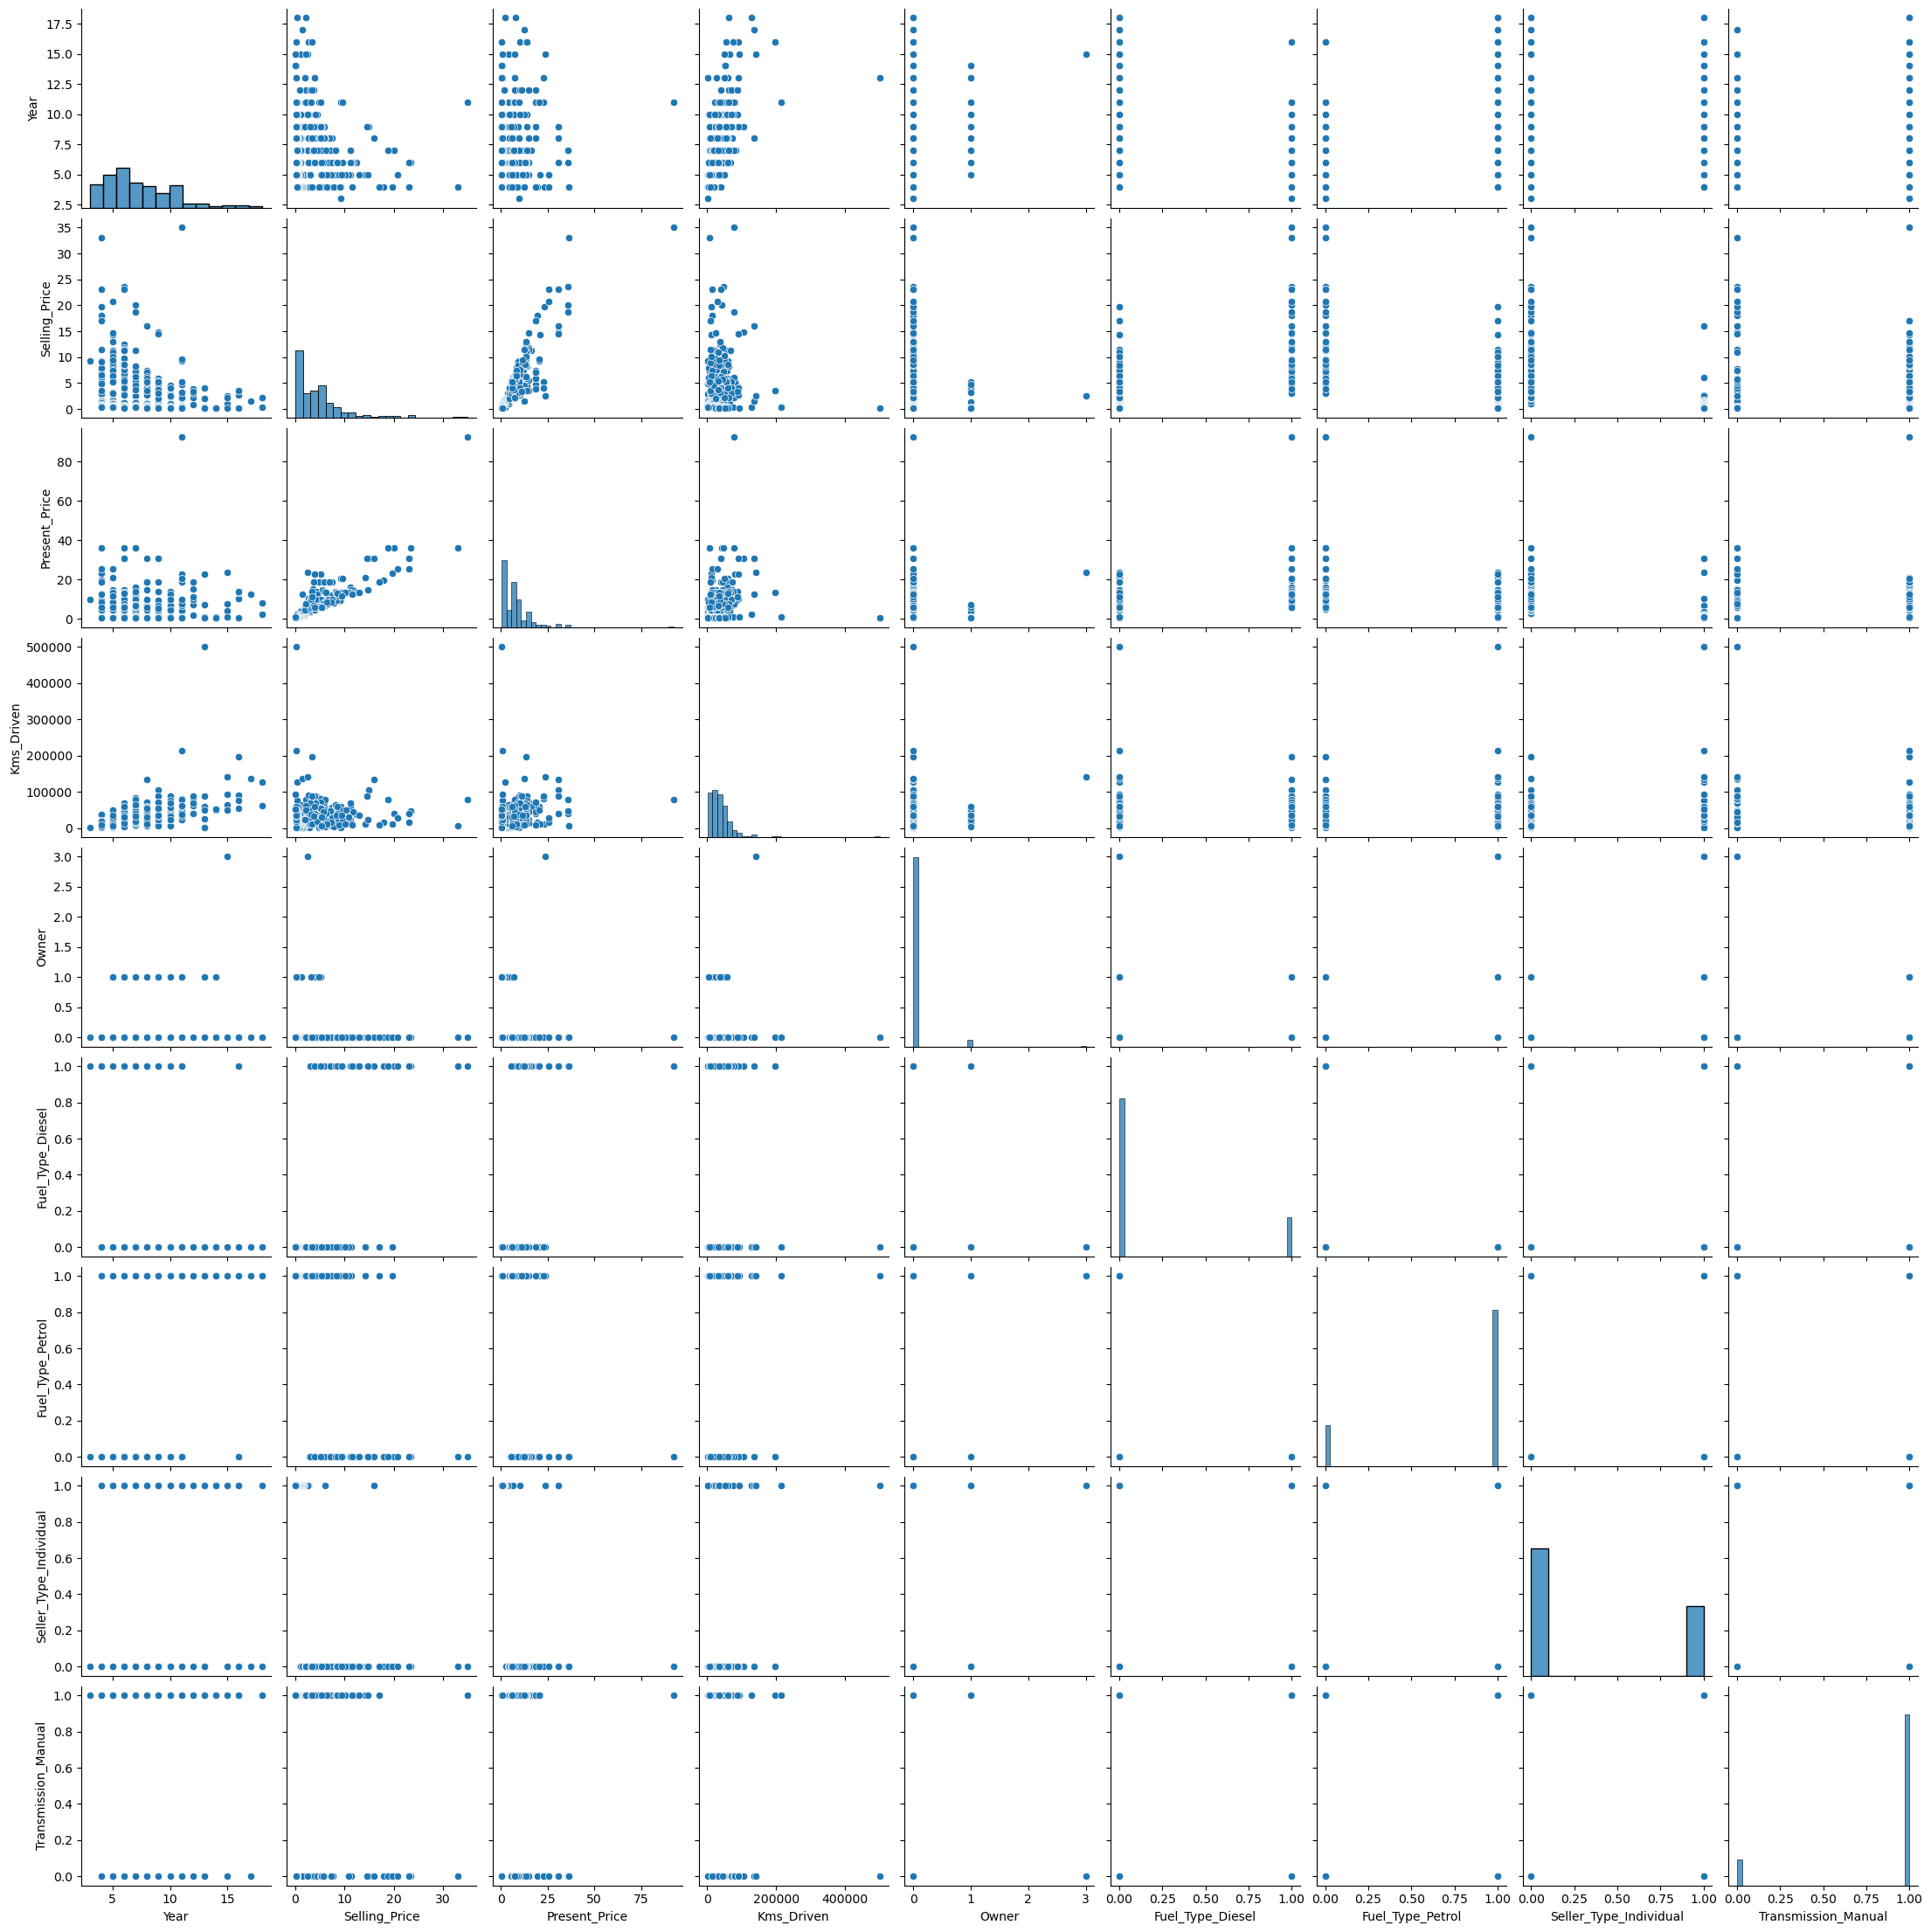

In [28]:
sns.pairplot(newdf)
plt.show()

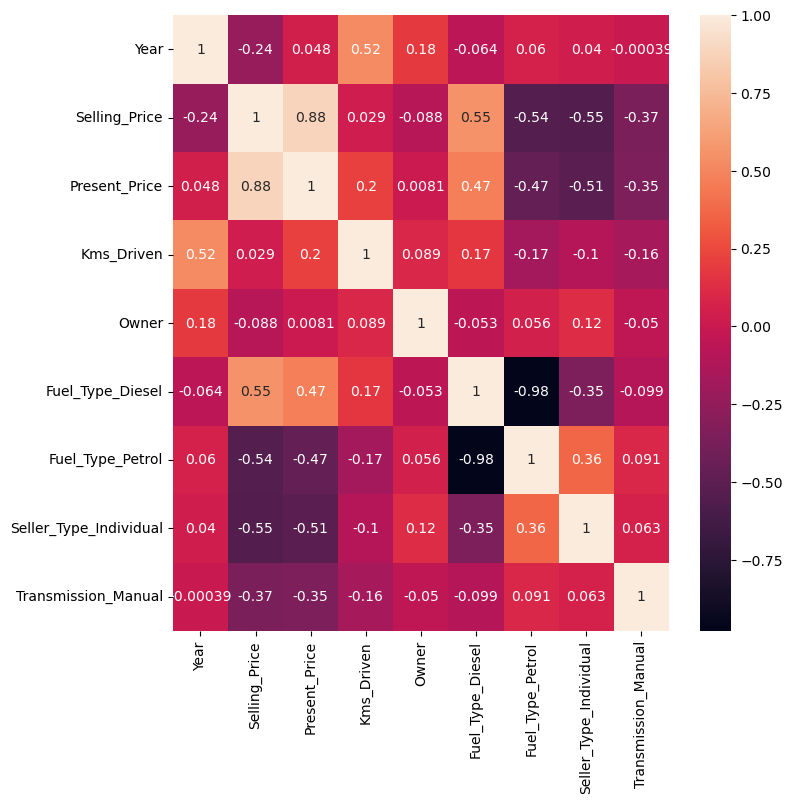

In [29]:
plt.figure(figsize = (8,8))
sns.heatmap(newdf.corr(), annot = True)
plt.show()

In [30]:
X = newdf[['Year', 'Present_Price', 'Kms_Driven', 'Owner',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual']]
y = newdf['Selling_Price']

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
xcolumns = X.columns.tolist()

In [34]:
X = scaler.fit_transform(X)

In [35]:
X = pd.DataFrame(X, columns = xcolumns)
X.head()

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,-0.128897,-0.236215,-0.256224,-0.174501,-0.498962,0.509327,-0.737285,0.39148
1,0.217514,0.221505,0.155911,-0.174501,2.004162,-1.963374,-0.737285,0.39148
2,-1.168129,0.257427,-0.773969,-0.174501,-0.498962,0.509327,-0.737285,0.39148
3,0.910335,-0.403079,-0.817758,-0.174501,-0.498962,0.509327,-0.737285,0.39148
4,-0.128897,-0.087890,0.141743,-0.174501,2.004162,-1.963374,-0.737285,0.39148


In [38]:
X.shape

(301, 8)

In [39]:
y.shape

(301,)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=100)

In [42]:
X_train.size

1680

In [43]:
X_test.size

728

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
model = LinearRegression()

In [46]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
model.score(X_train, y_train)

0.895560836468798

In [48]:
pd.DataFrame(model.coef_, index = X_test.columns, columns = ['Coefficeints'])

,Coefficeints
Year,-1.108809
Present_Price,3.484620
Kms_Driven,-0.185312
Owner,0.146933
Fuel_Type_Diesel,0.984041
Fuel_Type_Petrol,0.167000
Seller_Type_Individual,-0.536205
Transmission_Manual,-0.537119


In [49]:
y_pred = model.predict(X_test)

In [50]:
from sklearn import metrics

In [51]:
print ('Mean Squared Error is: ', metrics.mean_squared_error(y_test, y_pred))

Mean Squared Error is:  4.390781949926884


In [52]:
print('r2 Score is: ', metrics.r2_score(y_test, y_pred) )

r2 Score is:  0.8316982715837706


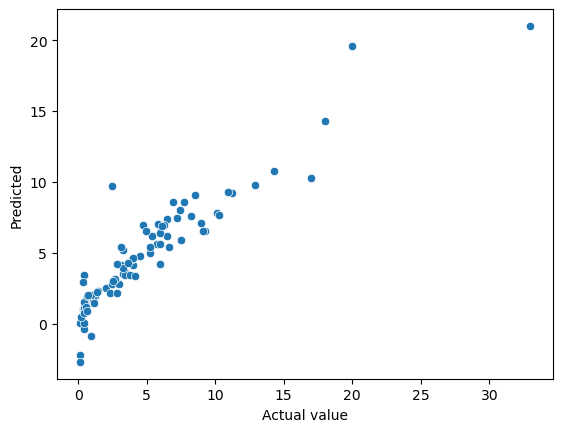

In [53]:
sns.scatterplot(x = y_test, y = y_pred)
plt.xlabel('Actual value')
plt.ylabel('Predicted')
plt.show()

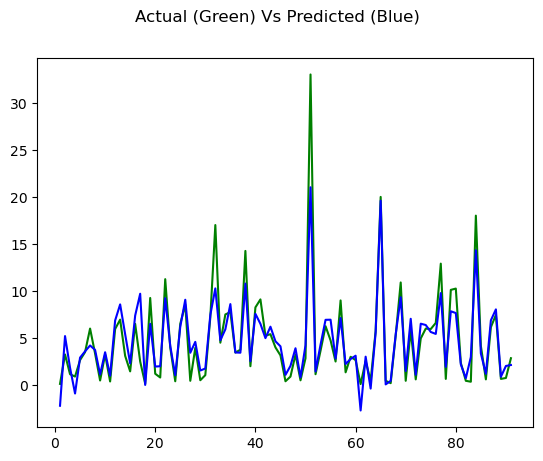

In [54]:
c = [i for i in range(1,92,1)]   #Creating an Index, 61 is used because we have a total of 60 data in our testing set
fig = plt.figure()
plt.plot(c,y_test, color = 'green') # Plotting y test
plt.plot(c,y_pred, color = 'blue') # Plotting predicted values
fig.suptitle('Actual (Green) Vs Predicted (Blue)') # Set title
plt.show()